# BXEB-L0280Z-50S1000-C-C3

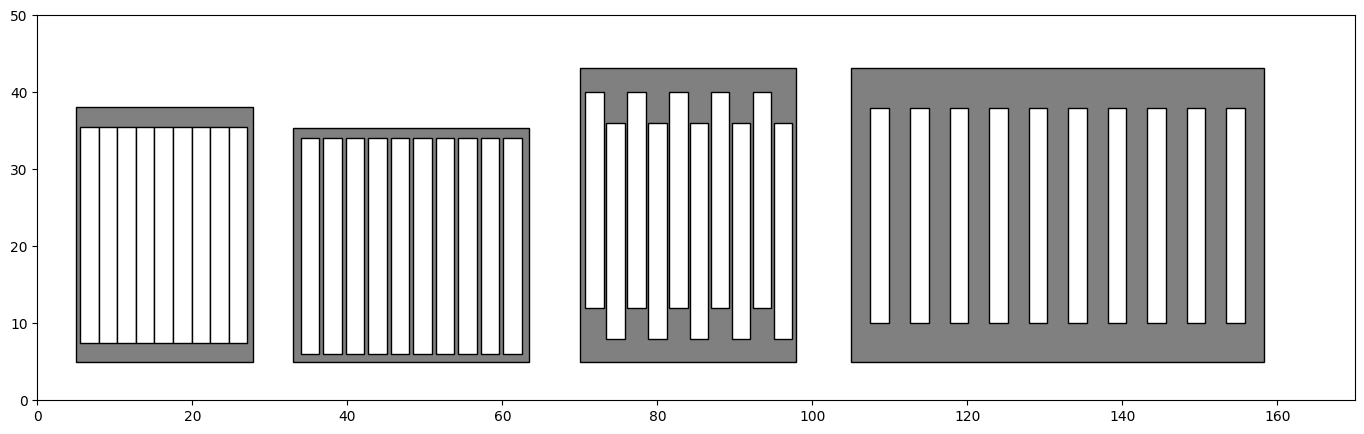

In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.axes import Axes

fig, ax = plt.subplots(figsize=(17, 5))

ax.add_patch(patches.Rectangle((5, 5), 22.8, 33.1, linewidth=1, edgecolor="black", facecolor="gray"))
for i in range(9):
    ax.add_patch(patches.Rectangle((5.5 + 2.4 * i, 7.5), 2.4, 28, linewidth=1, edgecolor="black", facecolor="white"))

ax.add_patch(patches.Rectangle((33, 5), 30.4, 30.4, linewidth=1, edgecolor="black", facecolor="gray"))
for i in range(10):
    ax.add_patch(patches.Rectangle((34 + 2.9 * i, 6), 2.4, 28, linewidth=1, edgecolor="black", facecolor="white"))

ax.add_patch(patches.Rectangle((70, 5), 27.9, 38.1, linewidth=1, edgecolor="black", facecolor="gray"))
for i in range(10):
    y = 2 if i % 2 == 0 else -2
    ax.add_patch(patches.Rectangle((70.7 + 2.7 * i, 10 + y), 2.4, 28, linewidth=1, edgecolor="black", facecolor="white"))

ax.add_patch(patches.Rectangle((105, 5), 53.3, 38.1, linewidth=1, edgecolor="black", facecolor="gray"))
for i in range(10):
    ax.add_patch(patches.Rectangle((107.5 + 5.1 * i, 10), 2.4, 28, linewidth=1, edgecolor="black", facecolor="white"))


ax.set_ylim(0, 50)
ax.set_xlim(0, 170)

plt.show()

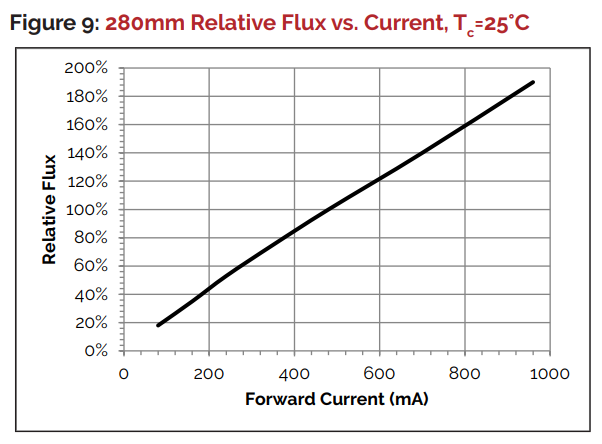
> The temperature is const here and, but in reality the higher the current the lower the efficiency is (and relative flux)  
> 480 mA (9.7W) -> 1345 lm (100%)  
> 350 mA (7W) -> 1010 lm

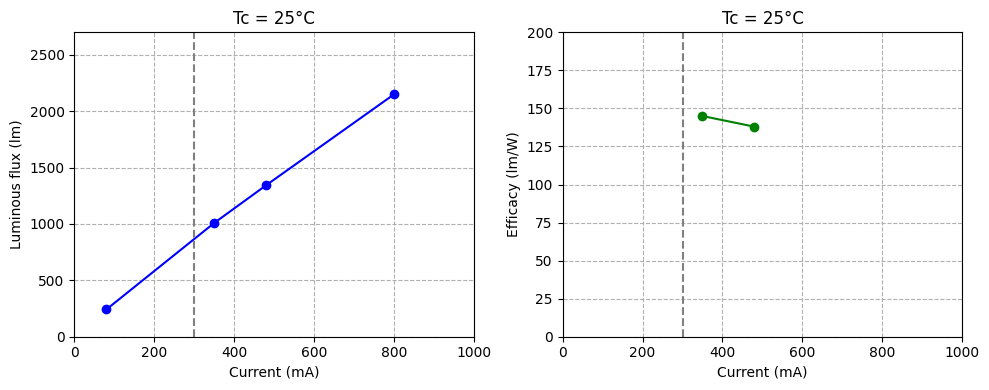

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1: Axes
ax2: Axes

my_current_ma = 300

# Luminous flux
ax1.set_title("Tc = 25°C")
flux_currents = [80, 350, 480, 800]
flux_values = [242, 1010, 1345, 2152]
ax1.plot(flux_currents, flux_values, marker='o', color='blue')
ax1.set_xlim(0, 1000)
ax1.set_ylim(0, 2700)
ax1.set_xlabel("Current (mA)")
ax1.set_ylabel("Luminous flux (lm)")
ax1.grid(True, linestyle='--')
ax1.axvline(my_current_ma, c="gray", linestyle="--")

# Efficacy
ax2.set_title("Tc = 25°C")
ax2.plot([350, 480], [145, 138], marker='o', color='green')
ax2.set_xlim(0, 1000)
ax2.set_ylim(0, 200)
ax2.set_xlabel("Current (mA)")
ax2.set_ylabel("Efficacy (lm/W)")
ax2.grid(True, linestyle='--')
ax2.axvline(my_current_ma, c="gray", linestyle="--")

plt.tight_layout()
plt.show()

In [3]:
import math
import numpy as np

def lumen_to_lux(lumens: float, distance_m: float, beam_angle_deg: float, loss_percentage: float = 30.0) -> float:
    if distance_m <= 0 or beam_angle_deg <= 0 or beam_angle_deg >= 180:
        raise ValueError("Distance must be > 0 and beam angle between 0 and 180. Stop breaking physics.")

    efficiency_multiplier = 1.0 - (loss_percentage / 100.0)
    effective_lumens = lumens * efficiency_multiplier

    # The radius of the light spot at the given distance
    # Angle is halved because of basic right-triangle trigonometry from the center
    angle_rad = math.radians(beam_angle_deg / 2.0)
    spot_radius_m = distance_m * math.tan(angle_rad)

    spot_area_sq_m = math.pi * (spot_radius_m ** 2)

    lux = effective_lumens / spot_area_sq_m
    return lux

lumens = np.interp(my_current_ma, flux_currents, flux_values)
print(f"1 LED: {lumens:.2f} lm @ {my_current_ma} mA")
print()

estimated_lux_one = lumen_to_lux(
    lumens=lumens, 
    distance_m=0.35, 
    beam_angle_deg=100.0,  # LED light isn't distributed evenly and LEDs are in a housing
    loss_percentage=30.0
)

led_volt = 20

for i in [1, *range(6, 11)]:
    estimated_lux = estimated_lux_one * i
    print(f"{i} LED(s): ~{estimated_lux:.2f} lx | ~{i * led_volt * my_current_ma / 1000} W")

1 LED: 867.78 lm @ 300 mA

1 LED(s): ~1111.34 lx | ~6.0 W
6 LED(s): ~6668.05 lx | ~36.0 W
7 LED(s): ~7779.39 lx | ~42.0 W
8 LED(s): ~8890.73 lx | ~48.0 W
9 LED(s): ~10002.08 lx | ~54.0 W
10 LED(s): ~11113.42 lx | ~60.0 W


In [80]:
width = 2.4 * 10
height = 28
f"{width * height:.2f} cm2", f"{width:.2f} cm x {height} cm"

('672.00 cm2', '24.00 cm x 28 cm')